In [17]:
#CELL 1 — Import & Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [18]:
#CELL 2 — Cleaning & Preprocessing

# Convert TotalCharges & handle missing values
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

# Identifikasi Outlier sederhana
# Simpan kolom numerik untuk dicek
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Drop kolom yang tidak relevan/redundant
# TotalCharges didrop karena multikolinearitas dengan tenure & MonthlyCharges
# CustomerID juga didrop karena bersifat unik
df.drop(columns=['customerID', 'TotalCharges'], inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Shape setelah cleaning:", df.shape)

Shape setelah cleaning: (7032, 19)


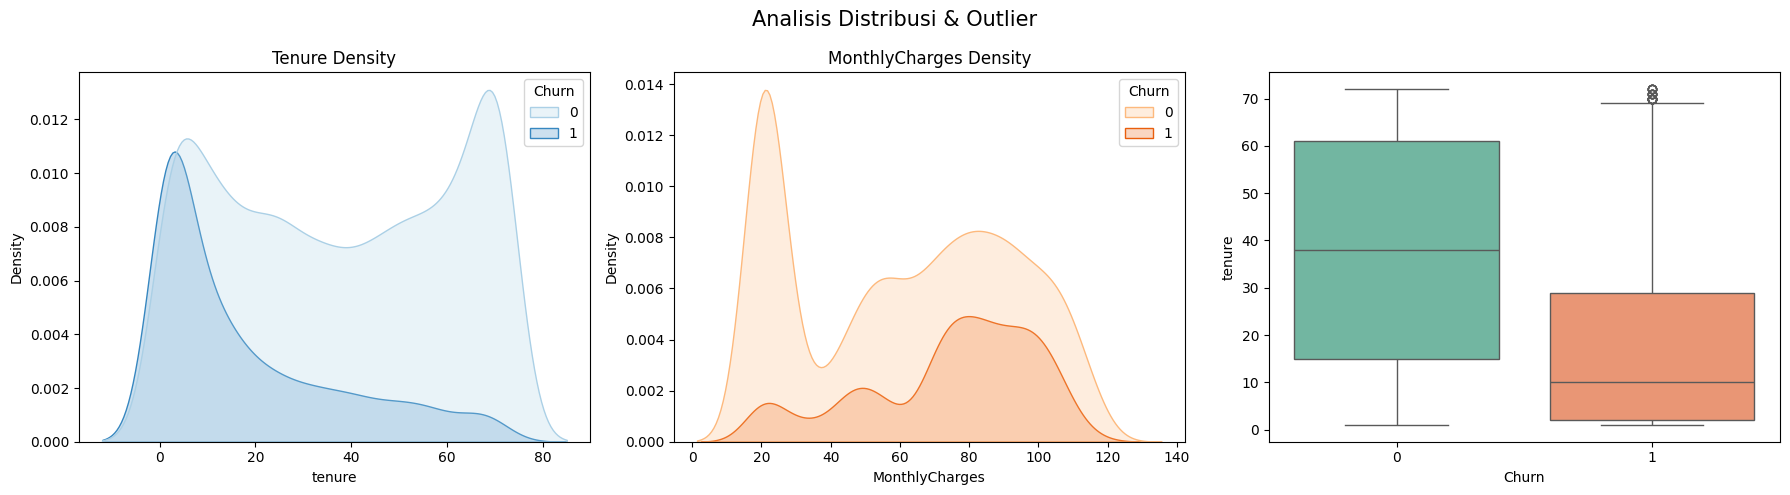

In [19]:
#CELL 3 - EDA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis Distribusi & Outlier', fontsize=15)

# Density Plot Tenure
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, ax=axes[0], palette='Blues')
axes[0].set_title('Tenure Density')

# Density Plot MonthlyCharges
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True, ax=axes[1], palette='Oranges')
axes[1].set_title('MonthlyCharges Density')

# Boxplot untuk cek Outlier
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', ax=axes[2], palette='Set2', legend=False)

plt.tight_layout(); plt.show()

In [20]:
#CELL 4 - Encoding & Split (Persiapan Data)

# 1. Pilih kolom kategori
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# 2. One-Hot Encoding (drop_first=True untuk menghindari jebakan variabel dummy)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. Pisahkan Fitur (X) dan Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 4. Train-Test Split (Gunakan stratify agar distribusi Churn seimbang di kedua set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Training: {X_train.shape}")
print(f"Data Testing: {X_test.shape}")
print(f"Churn rate di test set: {y_test.mean():.3f}")  # harus mirip 0.266

Data Training: (5625, 29)
Data Testing: (1407, 29)
Churn rate di test set: 0.266


In [21]:
#CELL 5 - MODELING
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline([
    ('rf', RandomForestClassifier(
        random_state=42,
        class_weight='balanced',

        # Information Gain
        criterion='entropy',

        # PRE-PRUNING
        max_features='sqrt'
    ))
])

# HYPERPARAMETER TUNING

param_grid = {

    # jumlah tree
    'rf__n_estimators': [100, 200],

    # batasi kedalaman tree
    'rf__max_depth': [4, 6, 8],

    # minimal data untuk split
    'rf__min_samples_split': [10, 20],

    # minimal data di leaf
    'rf__min_samples_leaf': [5, 10]
}

# ==========================================
# GRID SEARCH
# ==========================================

grid_rf = GridSearchCV(
    estimator=rf_pipe,

    param_grid=param_grid,

    cv=5,

    scoring='f1',

    n_jobs=-1
)

print("Sedang mencari parameter terbaik Random Forest...")

# TRAINING MODEL

grid_rf.fit(X_train, y_train)

# MODEL TERBAIK

best_rf = grid_rf.best_estimator_

print("\n=== PARAMETER TERBAIK RANDOM FOREST ===")

print(grid_rf.best_params_)

# TRAINING VS TEST SCORE

train_score = best_rf.score(X_train, y_train)

test_score = best_rf.score(X_test, y_test)

print("\n=== TRAINING & TEST SCORE ===")

print(f"Training Score : {train_score:.4f}")

print(f"Testing Score  : {test_score:.4f}")

print(f"Gap Score      : {(train_score - test_score):.4f}")

Sedang mencari parameter terbaik Random Forest...

=== PARAMETER TERBAIK RANDOM FOREST ===
{'rf__max_depth': 8, 'rf__min_samples_leaf': 5, 'rf__min_samples_split': 10, 'rf__n_estimators': 200}

=== TRAINING & TEST SCORE ===
Training Score : 0.7849
Testing Score  : 0.7420
Gap Score      : 0.0429


In [22]:
# CELL 6 — Evaluasi & Perbandingan Model

# 1. Melakukan Prediksi (Menggunakan best_rf dari Cell 5)
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# 2. Membuat tabel perbandingan metrik evaluasi
results = {
    'Random Forest (Tuned)': {
        'Accuracy':  round(accuracy_score(y_test, y_pred_rf), 4),
        'Precision': round(precision_score(y_test, y_pred_rf), 4),
        'Recall':    round(recall_score(y_test, y_pred_rf), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_rf), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob_rf), 4)
    }
}

comparison_df = pd.DataFrame(results).T

print("=== HASIL EVALUASI TEST SET ===")
print(comparison_df)

# 3. Classification Report (detail per kelas)
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_rf))

# CROSS VALIDATION
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=cv,
    scoring='roc_auc'
)

print("\n=== CROSS VALIDATION ROC-AUC ===")
print("Scores tiap fold:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

# OVERFITTING CHECK
train_pred = best_rf.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, y_pred_rf)

print("\n=== OVERFITTING CHECK ===")
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Testing Accuracy  : {test_acc:.4f}")

gap = train_acc - test_acc

print(f"Gap Accuracy      : {gap:.4f}")

=== HASIL EVALUASI TEST SET ===
                       Accuracy  Precision  Recall  F1-Score  ROC-AUC
Random Forest (Tuned)     0.742     0.5096  0.7834    0.6175   0.8375

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407


=== CROSS VALIDATION ROC-AUC ===
Scores tiap fold: [0.85060646 0.84945463 0.84270157 0.84501047 0.83959551]
Mean ROC-AUC: 0.845473727091292
Std ROC-AUC: 0.004114495826094882

=== OVERFITTING CHECK ===
Training Accuracy : 0.7849
Testing Accuracy  : 0.7420
Gap Accuracy      : 0.0429


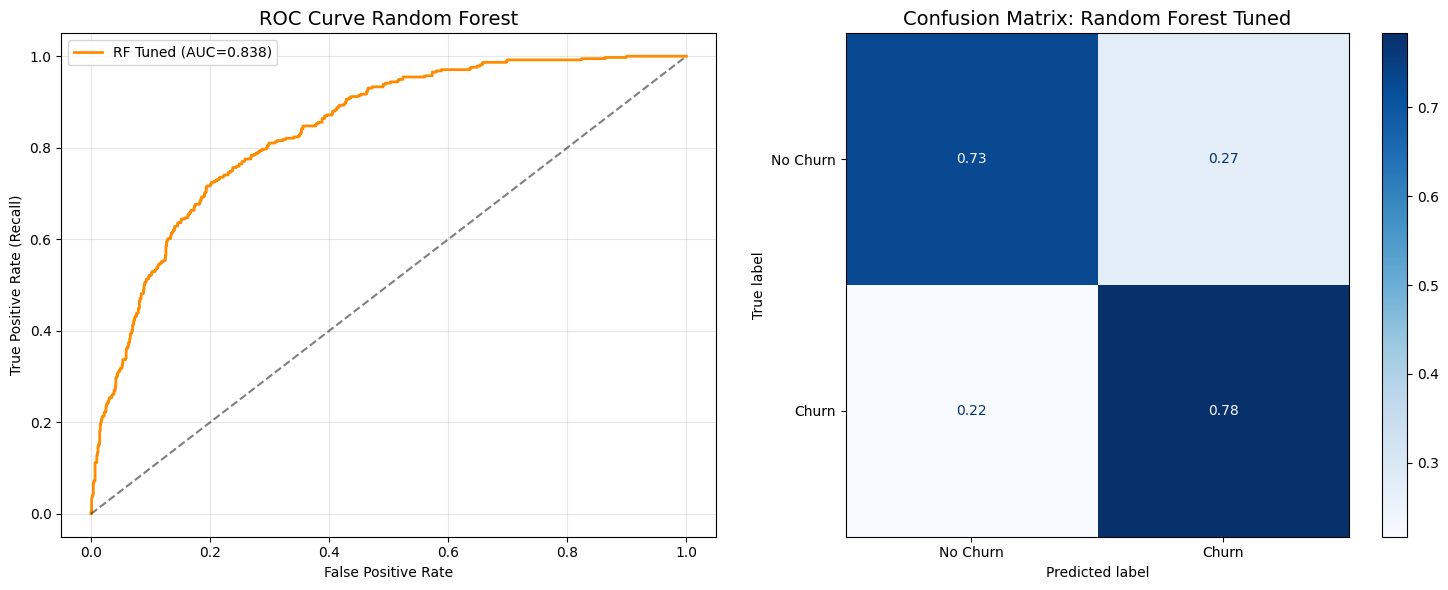

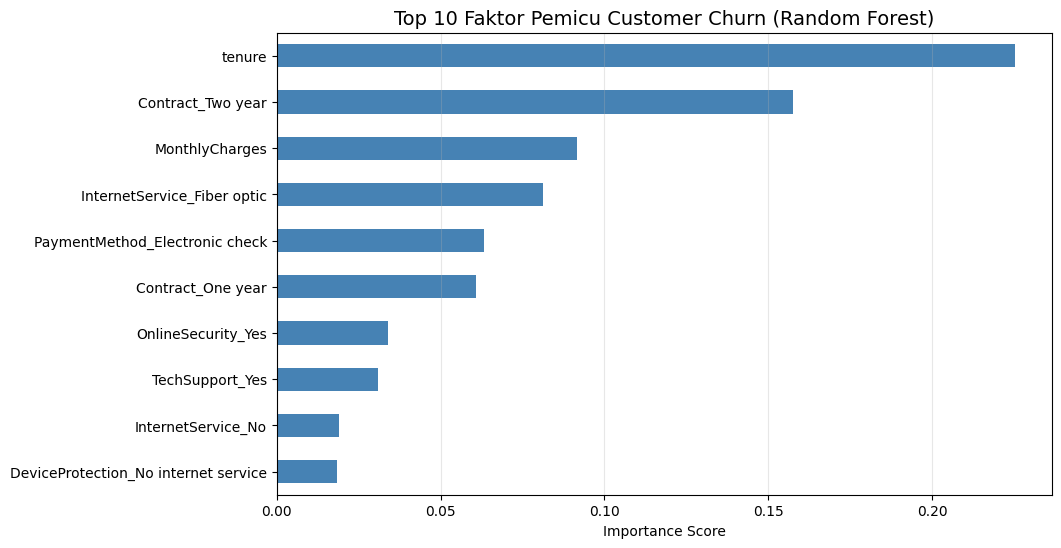

In [23]:
#CELL 7 — Visualisasi Hasil (ROC & Confusion Matrix)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve hanya Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[0].plot(fpr_rf, tpr_rf,
             label=f'RF Tuned (AUC={roc_auc_score(y_test, y_prob_rf):.3f})',
             color='darkorange', lw=2)

axes[0].plot([0,1],[0,1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve Random Forest', fontsize=14)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Confusion Matrix untuk RF Tuned (Hasil terbaik)
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['No Churn', 'Churn'],
    ax=axes[1], cmap='Blues',
    normalize='true'
)
axes[1].set_title('Confusion Matrix: Random Forest Tuned', fontsize=14)

plt.tight_layout()
plt.show()

# 3. Feature Importance (Faktor pendorong Churn)
plt.figure(figsize=(10, 6))
importances = pd.Series(best_rf.named_steps['rf'].feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='steelblue')

plt.title('Top 10 Faktor Pemicu Customer Churn (Random Forest)', fontsize=14)
plt.xlabel('Importance Score')

plt.grid(axis='x', alpha=0.3)

plt.show()